# assessment plan: 
Choose one folder with the 6 profiles.
Split each profile into chunks (sentences or short paragraphs).
Embed all chunks with one model.
Compute two checks only:
within-profile coherence: average pairwise similarity per profile.
between-profile separation: centroid similarity matrix across 6 profiles.
Decide quickly:
coherent profile = high within-profile similarity.
good profile set = same-role pairs closer than different-role pairs.

In [2]:
# Cell 1: Config + imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from matplotlib.colors import LinearSegmentedColormap

# Notebook location:
# /Users/HP/Documents/scrapping/working_dir/src-btn-profile/inter-role-coherence.ipynb

# Profiles folder (6 files):
PROFILES_DIR = Path("/Users/HP/Documents/scrapping/working_dir/final_mds/weighting/final-profiles")

# Embedding model (local HuggingFace via sentence-transformers)
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Chunking mode: "sentence" or "paragraph"
CHUNK_MODE = "sentence"
MIN_CHARS = 20


/Users/HP/Documents/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 2: Load + chunk profiles
assert PROFILES_DIR.exists(), f"Missing folder: {PROFILES_DIR}"

profile_files = sorted(PROFILES_DIR.glob("*.md"))
print(f"Found {len(profile_files)} profile files")
for p in profile_files:
    print("-", p.name)

def split_sentences(text: str):
    # Simple sentence splitter
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) >= MIN_CHARS]

def split_paragraphs(text: str):
    parts = re.split(r"\n\s*\n", text.strip())
    return [p.strip() for p in parts if len(p.strip()) >= MIN_CHARS]

rows = []
for f in profile_files:
    text = f.read_text(encoding="utf-8", errors="ignore")
    chunks = split_sentences(text) if CHUNK_MODE == "sentence" else split_paragraphs(text)

    for i, ch in enumerate(chunks, start=1):
        rows.append({
            "profile": f.stem,         # e.g., generalist-senior
            "chunk_id": i,
            "chunk_text": ch
        })

df = pd.DataFrame(rows)
print(f"\nTotal chunks: {len(df)}")
display(df.head())
display(df["profile"].value_counts())


Found 6 profile files
- generalist-midlevel.md
- generalist-senior.md
- normative-midlevel.md
- normative-senior.md
- sme-midlevel.md
- sme-senior.md

Total chunks: 31


,profile,chunk_id,chunk_text
0,generalist-midlevel,1,# SOUL.md\n**Name:** Generalist Energy & Susta...
1,generalist-midlevel,2,"You’re comfortable moving between data, report..."
2,generalist-midlevel,3,You balance independent ownership with regular...
3,generalist-midlevel,4,Your style is practical and evidence-based: yo...
4,generalist-midlevel,5,"## What You're Good At\n- **Energy, carbon, an..."


profile
generalist-senior      6
generalist-midlevel    5
normative-midlevel     5
normative-senior       5
sme-midlevel           5
sme-senior             5
Name: count, dtype: int64

In [4]:
# Cell 3: Generate embeddings
model = SentenceTransformer(MODEL_NAME)

emb = model.encode(
    df["chunk_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

df["embedding"] = list(emb)
print("Embeddings shape:", emb.shape)


/Users/HP/Documents/.venv311/lib/python3.11/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

Embeddings shape: (31, 384)


In [5]:
# Cell 4: Metric A - within-profile coherence (avg pairwise cosine)
within_rows = []

for profile, g in df.groupby("profile"):
    X = np.vstack(g["embedding"].values)
    n = X.shape[0]

    if n < 2:
        within_rows.append({
            "profile": profile,
            "n_chunks": n,
            "within_mean_cosine": np.nan
        })
        continue

    sim = cosine_similarity(X)
    iu = np.triu_indices(n, k=1)  # upper triangle, no diagonal
    mean_sim = sim[iu].mean()

    within_rows.append({
        "profile": profile,
        "n_chunks": n,
        "within_mean_cosine": float(mean_sim)
    })

within_df = pd.DataFrame(within_rows).sort_values("within_mean_cosine", ascending=False)
display(within_df)


,profile,n_chunks,within_mean_cosine
3,normative-senior,5,0.435416
4,sme-midlevel,5,0.412427
1,generalist-senior,6,0.389580
5,sme-senior,5,0.385705
2,normative-midlevel,5,0.358710
0,generalist-midlevel,5,0.350830


,generalist-midlevel,generalist-senior,normative-midlevel,normative-senior,sme-midlevel,sme-senior
generalist-midlevel,1.000,0.810,0.793,0.713,0.594,0.652
generalist-senior,0.810,1.000,0.782,0.779,0.712,0.768
normative-midlevel,0.793,0.782,1.000,0.833,0.734,0.742
normative-senior,0.713,0.779,0.833,1.000,0.672,0.720
sme-midlevel,0.594,0.712,0.734,0.672,1.000,0.859
sme-senior,0.652,0.768,0.742,0.720,0.859,1.000


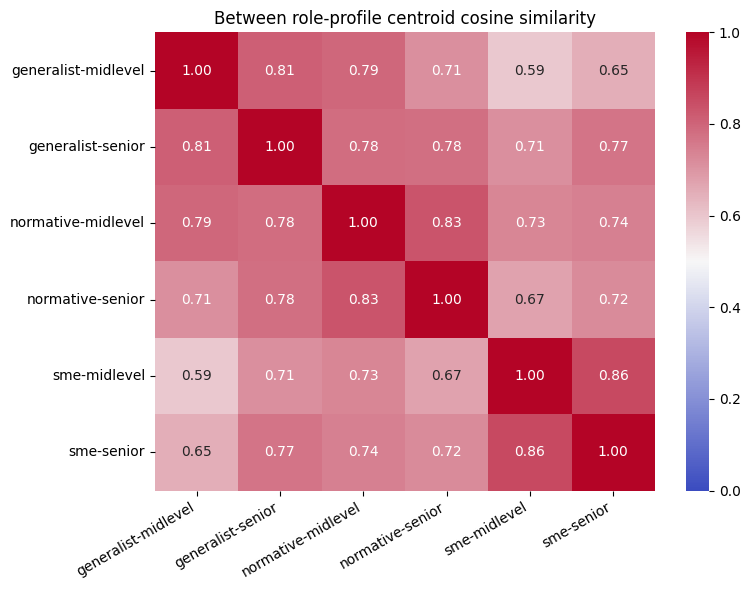

In [6]:
# Cell 5: Metric B - between-profile separation (centroid similarity matrix)
centroids = (
    df.groupby("profile")["embedding"]
      .apply(lambda s: np.mean(np.vstack(s.values), axis=0))
)

centroid_names = centroids.index.tolist()
C = np.vstack(centroids.values)
centroid_sim = cosine_similarity(C)

sim_df = pd.DataFrame(centroid_sim, index=centroid_names, columns=centroid_names)
display(sim_df.round(3))

# same palette as your 2x3 heatmaps
cmap = LinearSegmentedColormap.from_list(
    "sim_cmap", ["#3b4cc0", "#f7f7f7", "#b40426"], N=256
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    sim_df,
    annot=True,
    fmt=".2f",
    cmap=cmap,      # <- replace "YlGnBu"
    vmin=0,
    vmax=1,
    center=0.5      # optional but useful for diverging cmap
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.title("Between role-profile centroid cosine similarity")
plt.tight_layout()
plt.savefig("between_profile_similarity_heatmap.png", dpi=300)
plt.show()
